In [8]:
import pandas as pd
import os
import cv2
import numpy as np
import glob
from shutil import copyfile
from scipy.stats import entropy
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
# --- CONFIGURACIÓN ---
BASE_DATOS_DIR = 'Datos'
OUTPUT_DIR = os.path.join(BASE_DATOS_DIR, 'Dataset_Evolutivo_Simulado')
TRAIN_A_DIR = os.path.join(OUTPUT_DIR, 'train_A') # T0 (Inicial/Simple)
TRAIN_B_DIR = os.path.join(OUTPUT_DIR, 'train_B') # T1 (Avanzada/Compleja)

# Umbral para descartar imágenes que son idénticas (mismo zoom/luz)
# Si la diferencia de score es menor a esto, no hay "evolución" visible.
MIN_SCORE_DIFF = 0.5

In [3]:
print("Iniciando re-etiquetado inteligente...")

# 1. Mapeo de Imágenes (Igual que antes)
HAM_DIR = os.path.join(BASE_DATOS_DIR, 'HAM10000')
ISIC_DIR = os.path.join(BASE_DATOS_DIR, 'ISIC2018')
IMAGE_DIRS = [
    os.path.join(HAM_DIR, 'HAM10000_images_part_1'),
    os.path.join(HAM_DIR, 'HAM10000_images_part_2'),
    os.path.join(ISIC_DIR, 'ISIC2018_Task3_Training_Input')
]
METADATA_PATH = os.path.join(HAM_DIR, 'HAM10000_metadata.csv')

os.makedirs(TRAIN_A_DIR, exist_ok=True)
os.makedirs(TRAIN_B_DIR, exist_ok=True)

Iniciando re-etiquetado inteligente...


In [4]:
# Mapear rutas
image_path_map = {}
for folder in IMAGE_DIRS:
    for path in glob.glob(os.path.join(folder, '*.jpg')):
        image_id = os.path.splitext(os.path.basename(path))[0]
        image_path_map[image_id] = path

In [5]:
# 2. Función de "Score de Gravedad" (La Magia)
def get_severity_score(image_path):
    """Calcula qué tan 'avanzada' se ve una lesión basándose en entropía y color."""
    try:
        img = cv2.imread(image_path)
        if img is None: return 0
        img = cv2.resize(img, (256, 256))

        # A. Varianza de Color (Más colores = Más avanzado)
        # Calculamos la desviación estándar de los canales de color
        (mean, std) = cv2.meanStdDev(img)
        color_variance = np.mean(std)

        # B. Entropía de Textura (Más textura/desorden = Más avanzado)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        hist_norm = hist.ravel() / hist.sum()
        # Entropía de Shannon
        entropy_score = entropy(hist_norm, base=2)

        # Score Final Combinado (Ponderamos un poco más la entropía)
        # Ajusta estos pesos si ves que no ordena bien
        final_score = (color_variance * 0.4) + (entropy_score * 10.0)

        return final_score
    except Exception as e:
        print(f"Error procesando {image_path}: {e}")
        return 0

In [6]:
# 3. Procesar y Ordenar
df = pd.read_csv(METADATA_PATH)
lesion_groups = df.groupby('lesion_id')['image_id'].apply(list)
longitudinal_groups = lesion_groups[lesion_groups.apply(len) > 1]

print(f"Analizando {len(longitudinal_groups)} lesiones con múltiples imágenes...")

valid_pairs = 0
discarded_pairs = 0

for lesion_id, images in tqdm(longitudinal_groups.items()):

    # Obtener rutas y calcular scores para todas las imágenes de esta lesión
    scored_images = []
    for img_id in images:
        if img_id in image_path_map:
            path = image_path_map[img_id]
            score = get_severity_score(path)
            scored_images.append({'id': img_id, 'path': path, 'score': score})

    if len(scored_images) < 2:
        continue

    # ORDENAR: De menor score (T0) a mayor score (T1)
    # Esto fuerza a que T0 sea la más "simple" y T1 la más "compleja"
    scored_images.sort(key=lambda x: x['score'])

    t0_img = scored_images[0]  # La de menor entropía (inicio)
    t1_img = scored_images[-1] # La de mayor entropía (avanzado)

    # FILTRO: ¿Realmente hay diferencia visual?
    score_diff = t1_img['score'] - t0_img['score']

    if score_diff > MIN_SCORE_DIFF:
        # ¡Es un par válido! Hay evolución visual
        dest_filename = f"{lesion_id}_{t0_img['id']}.jpg"

        copyfile(t0_img['path'], os.path.join(TRAIN_A_DIR, dest_filename))
        copyfile(t1_img['path'], os.path.join(TRAIN_B_DIR, dest_filename))
        valid_pairs += 1
    else:
        # Son visualmente idénticas (solo zoom o rotación), descartar
        discarded_pairs += 1

print("\n--- Resultado del Re-etiquetado Inteligente ---")
print(f"Pares válidos generados (Evolución Visible): {valid_pairs}")
print(f"Pares descartados (Sin cambios/Solo zoom): {discarded_pairs}")
print(f"Dataset listo en: {OUTPUT_DIR}")

Analizando 1956 lesiones con múltiples imágenes...


1956it [00:32, 60.82it/s]


--- Resultado del Re-etiquetado Inteligente ---
Pares válidos generados (Evolución Visible): 1863
Pares descartados (Sin cambios/Solo zoom): 93
Dataset listo en: Datos\Dataset_Evolutivo_Simulado


In [7]:
def calcular_score_complejidad(imagen_rgb):
    """
    Calcula un score basado en la 'Regla del Caos':
    A mayor varianza de color y entropía de textura, más avanzada la lesión.
    """
    # 1. Varianza de Color (Desorden cromático)
    (mean, std) = cv2.meanStdDev(imagen_rgb)
    varianza_color = np.mean(std)

    # 2. Entropía de Textura (Desorden estructural)
    gray = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist_norm = hist.ravel() / hist.sum()
    score_entropia = entropy(hist_norm, base=2)

    # Score ponderado (Damos peso a la entropía porque indica cambios estructurales)
    score_final = (varianza_color * 0.4) + (score_entropia * 10.0)
    return score_final

In [9]:
def visualizar_evolucion_simulada(ruta_img_a, ruta_img_b):
    """
    Toma dos imágenes desordenadas, calcula su estadio evolutivo
    y las muestra ordenadas temporalmente (T0 -> T1).
    """
    # Cargar imágenes
    img_a = cv2.imread(ruta_img_a)
    img_b = cv2.imread(ruta_img_b)

    # Convertir a RGB para matplotlib
    img_a = cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB)
    img_b = cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB)

    # Calcular Scores
    score_a = calcular_score_complejidad(img_a)
    score_b = calcular_score_complejidad(img_b)

    # Lógica de Ordenamiento Temporal (Simulación de Evolución)
    if score_a < score_b:
        t0_img, t1_img = img_a, img_b
        t0_score, t1_score = score_a, score_b
    else:
        t0_img, t1_img = img_b, img_a
        t0_score, t1_score = score_b, score_a

    # Calcular el Delta de "Caos"
    delta_caos = t1_score - t0_score
    evolucion_estimada = "3 a 6 Meses" if delta_caos > 0.5 else "Cambios Mínimos (< 1 Mes)"

    # --- GRAFICAR ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    plt.suptitle(f"Simulación de Progresión de la Lesión: {evolucion_estimada}\n(Basado en Incremento de Entropía Visual)", fontsize=16)

    # Plot T0 (Inicio)
    axes[0].imshow(t0_img)
    axes[0].set_title(f"Tiempo T0 (Inicio)\nEstadio Temprano\nScore Complejidad: {t0_score:.2f}", color='green', fontsize=12)
    axes[0].axis('off')

    # Plot T1 (Evolución)
    axes[1].imshow(t1_img)
    axes[1].set_title(f"Tiempo T1 (Predicción Visual)\nEstadio Avanzado\nScore Complejidad: {t1_score:.2f}", color='red', fontsize=12)
    axes[1].axis('off')

    # Flecha de evolución
    fig.text(0.5, 0.5, '➔', ha='center', va='center', fontsize=50, color='gray', alpha=0.5)

    plt.tight_layout()
    plt.show()

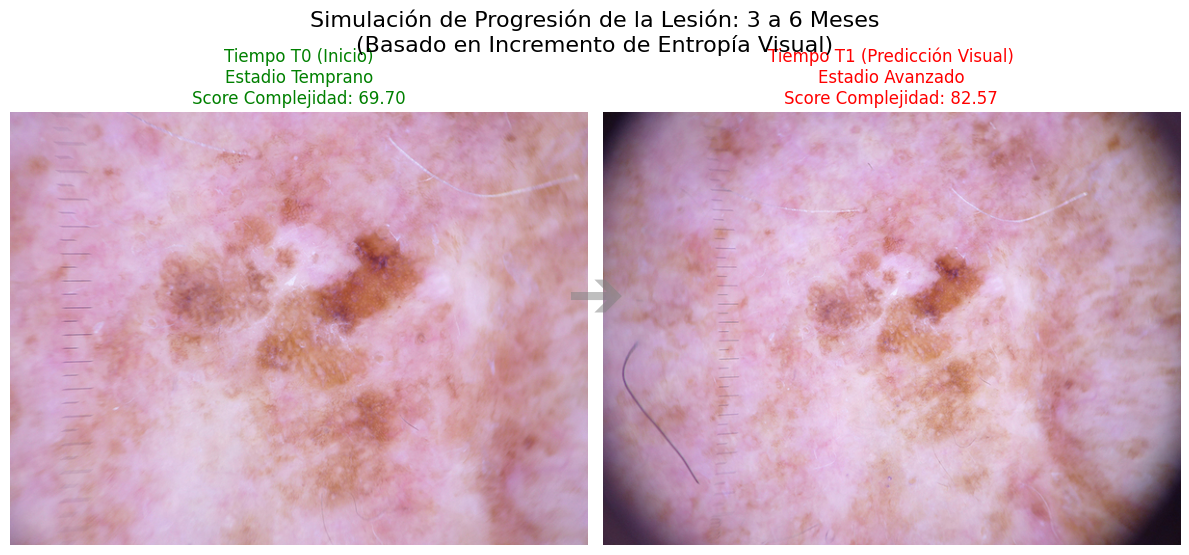

In [12]:
# --- EJEMPLO DE USO ---
# Reemplaza estas rutas con dos imágenes reales de tu carpeta de datos
# Trata de elegir dos que sean de la misma lesión (mismo ID ISIC/HAM)
ejemplo_ruta_1 = 'Datos/HAM10000/HAM10000_images_part_1/ISIC_0027419.jpg' # Pon aquí una ruta real
ejemplo_ruta_2 = 'Datos/HAM10000/HAM10000_images_part_1/ISIC_0025030.jpg' # Pon aquí otra ruta real (de la misma lesión)

# Si no tienes las rutas a mano, el código fallará al leer, asegúrate de que existan.
if os.path.exists(ejemplo_ruta_1) and os.path.exists(ejemplo_ruta_2):
    visualizar_evolucion_simulada(ejemplo_ruta_1, ejemplo_ruta_2)
else:
    print("Por favor, actualiza las variables 'ejemplo_ruta_1' y 'ejemplo_ruta_2' con rutas válidas de tu entorno.")